# Repulsive stiffness shaping — F vs d

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys
from glob import glob

sys.path.insert(0, os.path.join('../../'))
from plot_config import draw_radar, COLORS, FIG_W_SINGLE, FIG_W_DOUBLE, set_font_size
FIG_W = 10   # inches — change freely

FIG_H = 6    # inches — change freely

GRID = False
FONT_SIZE = 18  # pt — change to rescale all text uniformly
set_font_size(FONT_SIZE)
plt.rcParams['savefig.bbox'] = 'tight'   # export exactly the displayed (PNG) figure

# Shared data box so all normal-force-vs-distance plots match the stiffness sweeps
AX_RECT = [0.15, 0.17, 0.68, 0.76]

from UR5_codes.UR5_config import UR5_DESCENT
OUTPUT_DIR       = os.path.join('outputs', 'repulsive_stiffness_shaping')
COLORS           = plt.rcParams['axes.prop_cycle'].by_key()['color']
SIGMA            = 0.010
ACTIVATION_DEPTH = UR5_DESCENT / 2.0


def available_strengths():
    strengths = []
    for folder in glob(os.path.join(OUTPUT_DIR, 'strength_*')):
        name = os.path.basename(folder)
        try:
            strengths.append(float(name.split('_', 1)[1]))
        except ValueError:
            pass
    return sorted(strengths)


def load_runs(strength):
    s = str(int(strength)) if float(strength).is_integer() else str(strength)
    pattern = os.path.join(OUTPUT_DIR, f'strength_{s}', f'strength_{s}_run_*.csv')
    return [pd.read_csv(f) for f in sorted(glob(pattern))]


def select_phase(df, phase='descent'):
    if 'Phase' not in df.columns:
        return df
    dff = df[df['Phase'] == phase].copy()
    if dff.empty:
        return df
    return dff


def interp_disp(dfs, col, n_pts=500, phase='descent'):
    phase_dfs = [select_phase(df, phase).sort_values('UR5_displacement_m') for df in dfs]
    d_max = min(0.02, min(df['UR5_displacement_m'].max() for df in phase_dfs))
    d = np.linspace(0, d_max, n_pts)
    vals = np.array([np.interp(d, df['UR5_displacement_m'], df[col]) for df in phase_dfs])
    return d, vals


STRENGTH_SWEEP = available_strengths()
data = {s: load_runs(s) for s in STRENGTH_SWEEP}
for s, runs in data.items():
    print(f'strength={s:g} N/m  ->  {len(runs)} run(s)')

strength=0 N/m  ->  5 run(s)
strength=300 N/m  ->  5 run(s)
strength=600 N/m  ->  5 run(s)


## F vs d

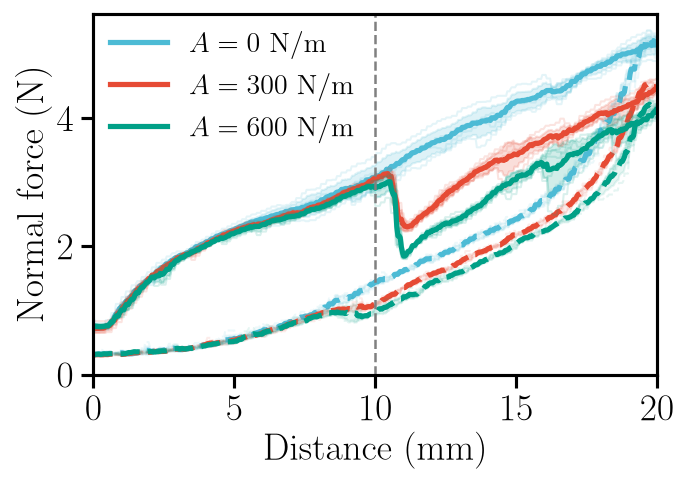

In [5]:
# ---- size / aspect for THIS graph only (shared style applies to the rest) ----
W_IN   = 8.5 * 0.65    # figure width (inches)
ASPECT = 5.15 / 9   # height / width  ->  set to change proportions
H_IN   = W_IN * ASPECT   # figure height (inches)

fig = plt.figure(figsize=(W_IN, H_IN))
ax = fig.add_axes(AX_RECT)

phase_specs = [
    ('descent', '-',  0.15, 0.18),
    ('ascent',  '--', 0.10, 0.10),
]

for idx, s in enumerate(STRENGTH_SWEEP):
    runs = data[s]
    if not runs:
        continue
    color = COLORS[idx % len(COLORS)]
    label = rf'$A = {s:g}$ N/m'

    for phase, linestyle, raw_alpha, band_alpha in phase_specs:
        d, vals = interp_disp(runs, 'Force_N', phase=phase)
        d_mm = d * 1e3
        mean, std = vals.mean(0), vals.std(0)

        for v in vals:
            ax.plot(d_mm, v, color=color, alpha=raw_alpha, linewidth=1, linestyle=linestyle)
        ax.plot(d_mm, mean, color=color, linewidth=2.5, linestyle=linestyle,
                label=label if phase == 'descent' else None)
        ax.fill_between(d_mm, mean - std, mean + std, color=color, alpha=band_alpha)

ax.axvline(ACTIVATION_DEPTH * 1e3, color='gray', linestyle='--',
           linewidth=1.2)
ax.set_xlabel('Distance (mm)')
ax.set_ylabel('Normal force (N)')
ax.legend(loc='upper left')
ax.set_xlim(0, 20)
ax.set_ylim(bottom=0)
os.makedirs(OUTPUT_DIR, exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, 'F_vs_d.pdf'))
plt.show()

## Gaussian virtual force vs d

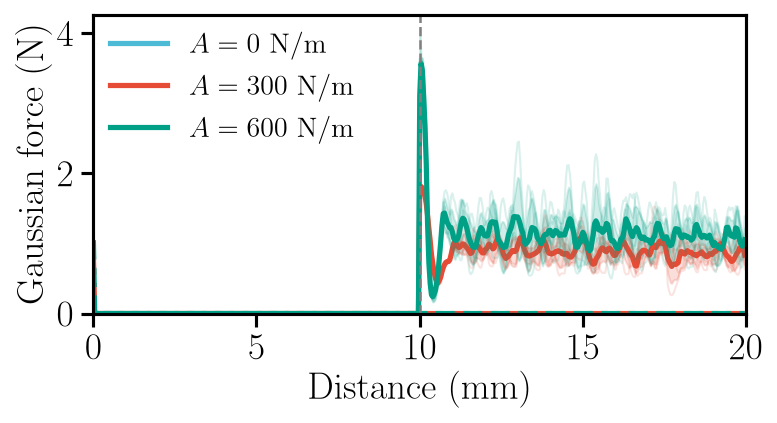

: 

In [ ]:
from KinematicsFinger.FK_Finger import joint_to_motor, FK_DIP
from ModelIDFinger.finger_params import c
from UR5_codes.UR5_config import FINGER_TARGET

r_tip = np.array([0, c, 0])
z_target = FK_DIP(joint_to_motor(FINGER_TARGET), r_tip)[2]

# ---- size / aspect for THIS graph only (shared style applies to the rest) ----
W_IN   = 8.5 * 0.65    # figure width (inches)
ASPECT = 5.15 / 9   # height / width  ->  set to change proportions
H_IN   = W_IN * ASPECT   # figure height (inches)

fig, ax = plt.subplots(figsize=(W_IN, H_IN))

phase_specs = [
    ('descent', '-',  0.15, 0.18),
    ('ascent',  '--', 0.10, 0.10),
]

for idx, s in enumerate(STRENGTH_SWEEP):
    runs = data[s]
    if not runs:
        continue
    color = COLORS[idx % len(COLORS)]
    label = rf'$A = {s:g}$ N/m'

    for phase, linestyle, raw_alpha, band_alpha in phase_specs:
        run_forces = []
        run_disps  = []
        for df in runs:
            dff = select_phase(df, phase=phase).copy()
            if dff.empty:
                continue
            q_m = np.radians(dff[['Motor1_pos_deg', 'Motor2_pos_deg']].to_numpy())
            z_tip = np.array([FK_DIP(q, r_tip)[2] for q in q_m])
            dz = z_tip - z_target
            A = dff['CartStrength_N_per_m'].to_numpy()
            sigma = dff['Sigma_m'].to_numpy()
            F = A * np.exp(-dz**2 / (2 * sigma**2)) * np.abs(dz)
            run_forces.append(F)
            run_disps.append(dff['UR5_displacement_m'].to_numpy())

        if not run_disps:
            continue

        d_max  = min(0.02, min(rd.max() for rd in run_disps))
        d_grid = np.linspace(0, d_max, 500)
        vals   = np.array([np.interp(d_grid, rd, rf) for rd, rf in zip(run_disps, run_forces)])
        d_mm   = d_grid * 1e3
        mean, std = vals.mean(0), vals.std(0)

        for v in vals:
            ax.plot(d_mm, v, color=color, alpha=raw_alpha, linewidth=1, linestyle=linestyle)
        ax.plot(d_mm, mean, color=color, linewidth=2.5, linestyle=linestyle,
                label=label if phase == 'descent' else None)
        ax.fill_between(d_mm, mean - std, mean + std, color=color, alpha=band_alpha)

ax.axvline(ACTIVATION_DEPTH * 1e3, color='gray', linestyle='--',
           linewidth=1.2)
ax.set_xlabel('Distance (mm)')
ax.set_ylabel('Gaussian force (N)')
ax.legend()
ax.set_xlim(0, 20)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gaussian_force_vs_d.pdf'))
plt.show()